# Практическое занятие: анализ событий безопасности на примере журналов событий безопасности ОС Windows

**Цель занятия:** Рассмотреть различные методы ручного и автоматизированного анализа журналов событий с целью формирования в итоге правил выявления признаков инцидентов ИБ на языке EPL

**План**

1. Загрузка журнала событий и нормализация с помощью `pygrok`, перевод в формат `pandas.DataFrame`.
2. Разбиение потока событий на отдельные сеансы с помощью идентификатора `LogonId`.
3. Использование метода префиксных деревьев для поиска подозрительных цепочек событий.
4. Выполнение задачи наблюдения за пользователем (Identity tracking): построение расширенного сеанса пользователя за пределами одного узла.
5. Использование обогащения событий (на примере GeoIP) и применение графовых представлений для поиска аномальных цепочек событий.
6. Знакомство с датасетом OTRF Security Datasets (Mordor)

## 0. Зависимости и подготовка окружения

In [75]:
# Установите недостающие пакеты, если их нет
# conda install  pandas numpy networkx matplotlib scikit-learn
# пакет pygrok отсутствует в репозитории conda, поэтому его ставим просто с помощью pip
# pip install pygrok

import json, math


from collections import defaultdict, Counter
from pathlib import Path



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (10, 4)

## 1. Загрузка журнала событий и нормализация с помощью pygrok, перевод в формат pandas.DataFrame

### 1.1. Источник данных



In [91]:
with open("event_data.json", encoding="utf-8") as f:
    raw_events = json.load(f)

In [92]:
len(raw_events)

135

In [93]:
raw_events[0]

{'@timestamp': '2026-04-01T08:00:00Z',
 'Hostname': 'DC01',
 'EventID': 4624,
 'Channel': 'Security',
 'TargetDomainName': 'CORP',
 'TargetUserName': 'alice',
 'TargetLogonId': '0xBDE640F',
 'LogonType': 2,
 'IpAddress': '10.0.1.25',
 'WorkstationName': 'DC01',
 'LogonGuid': '{46685257-7248-4771-347A-10456C031199}',
 'ProcessName': 'C:\\Windows\\System32\\winlogon.exe',
 'SubjectUserName': '-',
 'SubjectLogonId': '0x0',
 'raw_message': 'An account was successfully logged on.\nSubject:\n  Account Name: -\n  Logon ID: 0x0\nNew Logon:\n  Account Name: alice\n  Account Domain: CORP\n  Logon ID: 0xBDE640F\n  Logon GUID: {46685257-7248-4771-347A-10456C031199}\nLogon Type: 2\nNetwork Information:\n  Workstation Name: DC01\n  Source Network Address: 10.0.1.25'}

### 1.2. Нормализация с помощью pygrok

Сырое поле `raw_message` имеет формат, в котором Windows EventLog отображает событие в текстовом виде. Эти строки удобно нормализовать шаблонами grok.

Здесь мы задаём паттерны для интересующих нас EventID и вытаскиваем структурированные поля.

Список Event ID, для которых проводится анализ:

| Event ID| Описание    |
|---------|-------------|
| 4624    | Успешный вход пользователя |
| 4625    | Неуспешная попытка входа   |
| 4634    | Выход пользователя из системы |
| 4672    | Присвоение особых привилегий новому входу |
| 4688    | Создан новый процесс |
| 4663    | Попытка доступа к объекту |

In [94]:
from pygrok import Grok

CUSTOM_PATTERNS = {
    "WINUSER":   r"[A-Za-z0-9_.\-$]+",
    "WINDOMAIN": r"[A-Za-z0-9_.\-]+",
    "HEXID":     r"0x[0-9A-Fa-f]+",
    "GUIDX":     r"\{%{UUID}\}",
}

GROK_4624 = Grok(
    r"An account was successfully logged on\.\s+"
    r"Subject:\s+Account Name:\s+%{WINUSER:subject_user}\s+Logon ID:\s+%{HEXID:subject_logon_id}\s+"
    r"New Logon:\s+Account Name:\s+%{WINUSER:target_user}\s+Account Domain:\s+%{WINDOMAIN:target_domain}\s+"
    r"Logon ID:\s+%{HEXID:target_logon_id}\s+Logon GUID:\s+(?:%{GUIDX:logon_guid}|-)\s+"
    r"Logon Type:\s+%{INT:logon_type:int}\s+"
    r"Network Information:\s+Workstation Name:\s+%{WINUSER:workstation}\s+Source Network Address:\s+%{IP:src_ip}",
    custom_patterns=CUSTOM_PATTERNS,
)
GROK_4625 = Grok(
    r"An account failed to log on\.\s+Account Name:\s+%{WINUSER:target_user}\s+Account Domain:\s+%{WINDOMAIN:target_domain}\s+"
    r"Failure Information:\s+Sub Status:\s+%{HEXID:sub_status}\s+Logon Type:\s+%{INT:logon_type:int}\s+"
    r"Source Network Address:\s+%{IP:src_ip}",
    custom_patterns=CUSTOM_PATTERNS,
)
GROK_4634 = Grok(
    r"An account was logged off\.\s+Account Name:\s+%{WINUSER:target_user}\s+Logon ID:\s+%{HEXID:target_logon_id}\s+Logon Type:\s+(?:%{INT:logon_type:int}|-)",
    custom_patterns=CUSTOM_PATTERNS,
)
GROK_4672 = Grok(
    r"Special privileges assigned to new logon\.\s+Account Name:\s+%{WINUSER:subject_user}\s+Logon ID:\s+%{HEXID:subject_logon_id}\s+Privileges:\s+%{GREEDYDATA:privileges}",
    custom_patterns=CUSTOM_PATTERNS,
)
GROK_4688 = Grok(
    r"A new process has been created\.\s+Creator Subject:\s+Account Name:\s+%{WINUSER:subject_user}\s+Logon ID:\s+%{HEXID:subject_logon_id}\s+"
    r"Process Information:\s+New Process Name:\s+%{GREEDYDATA:process_name}\s+Command Line:\s+%{GREEDYDATA:cmdline}\s+Creator Process Name:\s+%{GREEDYDATA:parent_process}",
    custom_patterns=CUSTOM_PATTERNS,
)
GROK_4663 = Grok(
    r"An attempt was made to access an object\.\s+Account Name:\s+%{WINUSER:subject_user}\s+Logon ID:\s+%{HEXID:subject_logon_id}\s+"
    r"Object Name:\s+%{GREEDYDATA:object_name}\s+Access Mask:\s+%{HEXID:access_mask}",
    custom_patterns=CUSTOM_PATTERNS,
)

GROK_DISPATCH = {
    4624: GROK_4624, 4625: GROK_4625, 4634: GROK_4634,
    4672: GROK_4672, 4688: GROK_4688, 4663: GROK_4663,
}

In [95]:
def normalize_event(ev):
    """Возвращает плоский dict с унифицированной схемой полей.

    """
    eid = int(ev.get("EventID",0))
    out = {
        "ts": pd.to_datetime(ev.get("@timestamp")),
        "host": ev.get("Hostname"),
        "channel": ev.get("Channel", "Security"),
        "event_id": eid,
        "raw_message": ev.get("raw_message"),
        "target_user": None, "target_domain": None, "target_logon_id": None,
        "subject_user": None, "subject_logon_id": None,
        "logon_type": None, "src_ip": None, "workstation": None, "logon_guid": None,
        "process_name": None, "cmdline": None, "parent_process": None,
        "privileges": None, "object_name": None, "access_mask": None,
        "sub_status": None,
    }

    grok = GROK_DISPATCH.get(eid)
    if grok is not None and out["raw_message"]:
        m = grok.match(out["raw_message"])
        if m:
            for k, v in m.items():
                out[k] = v

    return out

normalized = [normalize_event(e) for e in raw_events]
df = pd.DataFrame(normalized).sort_values("ts").reset_index(drop=True)
print(f"Нормализовано событий: {len(df)}")
df.head(3).T

Нормализовано событий: 135


,0,1,2
ts,2026-04-01 08:00:00+00:00,2026-04-01 08:00:02+00:00,2026-04-01 08:02:00+00:00
host,DC01,DC01,DC01
channel,Security,Security,Security
event_id,4624,4672,4688
raw_message,An account was successfully logged on.\nSubjec...,Special privileges assigned to new logon.\n A...,A new process has been created.\nCreator Subje...
target_user,alice,None,None
target_domain,CORP,None,None
target_logon_id,0xBDE640F,None,None
subject_user,-,alice,alice
subject_logon_id,0x0,0xBDE640F,0xBDE640F


### 1.3. Базовый EDA

В событиях безопасности чаще всего встречаются категориальные признаки, которые чаще всего имеют числовые коды в "сыром" формате события. Важно понимать семантику этих признаков для их корректного анализа. 


Количественные методы анализа малоэффективны для событий безопасности, но некоторые общие сведения, например, распределение количества событий по типам/времени может дать общую информацию о том, что происходит с системой.


Ниже мы рассмотрим наиболее простые и при этом информативные признаки событий: Event ID, сетевой узел, на котором зарегистрировано событие и способ входа пользователя (присутствует не во всех событиях). 

Способ входа - это закодированный числом категориальный признак, поэтому для его интерпретации требюуется дополнительная информация. Сведения об основных способах входа приведены ниже.
| LogonType | Описание |
|-----------|----------|
| 2 | Интерактивный вход |
| 3 | Сетевой вход |
| 4 | Вход в качестве пакетного задания |
| 5 | Вход в качестве сервиса |
| 10 | Интерактивный удаленный (RDP) |

EventID распределение:
event_id
4624    21
4625     6
4634    18
4663     1
4672    13
4688    74
4720     1
4732     1

Хосты: host
WS01          48
DC01          41
WS02          21
FILESERVER    16
WS03           9

LogonType: logon_type
NaN    90
3.0    23
2.0    22


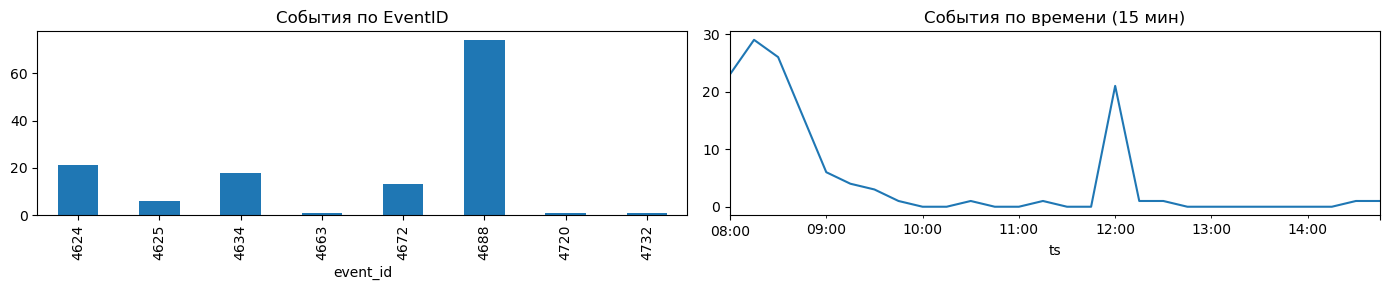

In [96]:
print("EventID распределение:")
print(df["event_id"].value_counts().sort_index().to_string())
print("\nХосты:", df["host"].value_counts().to_string())
print("\nLogonType:", df["logon_type"].value_counts(dropna=False).to_string())

fig, ax = plt.subplots(1, 2, figsize=(14, 3))
df["event_id"].value_counts().sort_index().plot(kind="bar", ax=ax[0], title="События по EventID")
df.set_index("ts").assign(c=1)["c"].resample("15min").sum().plot(ax=ax[1], title="События по времени (15 мин)")
plt.tight_layout(); plt.show()

In [97]:
df[df['ts'] > '2026-04-01 11:30:00+00:00']

,ts,host,channel,event_id,raw_message,target_user,target_domain,target_logon_id,subject_user,subject_logon_id,logon_type,src_ip,workstation,logon_guid,process_name,cmdline,parent_process,privileges,object_name,access_mask,sub_status
110,2026-04-01 12:12:00+00:00,WS02,Security,4625,An account failed to log on.\n Account Name: ...,frank,CORP,None,None,None,3.0,203.0.113.66,None,None,None,None,None,None,None,None,0xC000006A
111,2026-04-01 12:12:07+00:00,WS02,Security,4625,An account failed to log on.\n Account Name: ...,frank,CORP,None,None,None,3.0,203.0.113.66,None,None,None,None,None,None,None,None,0xC000006A
112,2026-04-01 12:12:14+00:00,WS02,Security,4625,An account failed to log on.\n Account Name: ...,frank,CORP,None,None,None,3.0,203.0.113.66,None,None,None,None,None,None,None,None,0xC000006A
113,2026-04-01 12:12:21+00:00,WS02,Security,4625,An account failed to log on.\n Account Name: ...,frank,CORP,None,None,None,3.0,203.0.113.66,None,None,None,None,None,None,None,None,0xC000006A
114,2026-04-01 12:12:28+00:00,WS02,Security,4625,An account failed to log on.\n Account Name: ...,frank,CORP,None,None,None,3.0,203.0.113.66,None,None,None,None,None,None,None,None,0xC000006A
115,2026-04-01 12:12:35+00:00,WS02,Security,4625,An account failed to log on.\n Account Name: ...,frank,CORP,None,None,None,3.0,203.0.113.66,None,None,None,None,None,None,None,None,0xC000006A
116,2026-04-01 12:13:00+00:00,WS02,Security,4624,An account was successfully logged on.\nSubjec...,frank,CORP,0x21F8AC6,-,0x0,3.0,203.0.113.66,ATTACKER,{EEEA163E-2338-7D12-BD32-50C448F4EF12},None,None,None,None,None,None,None
117,2026-04-01 12:13:02+00:00,WS02,Security,4672,Special privileges assigned to new logon.\n A...,None,None,None,frank,0x21F8AC6,NaN,None,None,None,None,None,None,"SeDebugPrivilege,SeImpersonatePrivilege,SeTcbP...",None,None,None
118,2026-04-01 12:13:15+00:00,WS02,Security,4688,A new process has been created.\nCreator Subje...,None,None,None,frank,0x21F8AC6,NaN,None,None,None,C:\Windows\System32\cmd.exe,cmd.exe /c whoami /all,C:\Windows\System32\services.exe,None,None,None,None
119,2026-04-01 12:13:25+00:00,WS02,Security,4688,A new process has been created.\nCreator Subje...,None,None,None,frank,0x21F8AC6,NaN,None,None,None,C:\Windows\System32\WindowsPowerShell\v1.0\pow...,powershell.exe -nop -w hidden -enc SQBFAFgAIAA...,C:\Windows\System32\cmd.exe,None,None,None,None


In [177]:
df[df['event_id'] == 4625]

,ts,host,channel,event_id,raw_message,target_user,target_domain,target_logon_id,subject_user,subject_logon_id,logon_type,src_ip,workstation,logon_guid,process_name,cmdline,parent_process,privileges,object_name,access_mask,sub_status,member_name,group_name,session_key,process_base
110,2026-04-01 12:12:00+00:00,WS02,Security,4625,An account failed to log on.\n Account Name: ...,frank,CORP,None,None,None,3.0,203.0.113.66,None,None,None,None,None,None,None,None,0xC000006A,None,None,None,-
111,2026-04-01 12:12:07+00:00,WS02,Security,4625,An account failed to log on.\n Account Name: ...,frank,CORP,None,None,None,3.0,203.0.113.66,None,None,None,None,None,None,None,None,0xC000006A,None,None,None,-
112,2026-04-01 12:12:14+00:00,WS02,Security,4625,An account failed to log on.\n Account Name: ...,frank,CORP,None,None,None,3.0,203.0.113.66,None,None,None,None,None,None,None,None,0xC000006A,None,None,None,-
113,2026-04-01 12:12:21+00:00,WS02,Security,4625,An account failed to log on.\n Account Name: ...,frank,CORP,None,None,None,3.0,203.0.113.66,None,None,None,None,None,None,None,None,0xC000006A,None,None,None,-
114,2026-04-01 12:12:28+00:00,WS02,Security,4625,An account failed to log on.\n Account Name: ...,frank,CORP,None,None,None,3.0,203.0.113.66,None,None,None,None,None,None,None,None,0xC000006A,None,None,None,-
115,2026-04-01 12:12:35+00:00,WS02,Security,4625,An account failed to log on.\n Account Name: ...,frank,CORP,None,None,None,3.0,203.0.113.66,None,None,None,None,None,None,None,None,0xC000006A,None,None,None,-


### 1.4. Расширение шаблонов grok на EventID 4720 и 4732

В реальной атаке после получения привилегий злоумышленник часто **создаёт «закладочную» учётную запись** и добавляет её в группу `Administrators`. Это даёт ему вход даже после смены пароля захваченного администратора. Такие действия демаскируются двумя EventID:

* **4720** — *«A user account was created»*. Поля: `New Account` (созданный пользователь), `Subject` (кто создал).
* **4732** — *«A member was added to a security-enabled local group»*. Поля: `Member` (добавленный SID/имя), `Group Name`.

Расширим словарь pygrok соответствующими типами событий.

In [98]:
# 1.4.2. Регистрируем grok-паттерны для 4720 и 4732
GROK_4720 = Grok(
    r'A user account was created\.\s+'
    r'Subject:\s+Account Name:\s+%{WINUSER:subject_user}\s+Logon ID:\s+%{HEXID:subject_logon_id}\s+'
    r'New Account:\s+Account Name:\s+%{WINUSER:target_user}\s+Account Domain:\s+%{WINDOMAIN:target_domain}',
    custom_patterns=CUSTOM_PATTERNS,
)
GROK_4732 = Grok(
    r'A member was added to a security-enabled local group\.\s+'
    r'Subject:\s+Account Name:\s+%{WINUSER:subject_user}\s+Logon ID:\s+%{HEXID:subject_logon_id}\s+'
    r'Member:\s+Account Name:\s+%{GREEDYDATA:member_name}\s+'
    r'Group:\s+Group Name:\s+%{WINUSER:group_name}',
    custom_patterns=CUSTOM_PATTERNS,
)
GROK_DISPATCH[4720] = GROK_4720
GROK_DISPATCH[4732] = GROK_4732

# Расширим нормализатор полем member_name/group_name
def normalize_event_v2(ev):
    out = normalize_event(ev)
    out.setdefault('member_name', None)
    out.setdefault('group_name', None)
    eid = out['event_id']
    grok = GROK_DISPATCH.get(eid)
    if grok is not None and out['raw_message']:
        m = grok.match(out['raw_message'])
        if m:
            for k, v in m.items():
                if k in ('member_name','group_name') and out.get(k) in (None,'','-'):
                    out[k] = v
    return out

extra_normalized = [normalize_event_v2(e) for e in raw_events]
df = pd.DataFrame(extra_normalized)

df = df.sort_values('ts').reset_index(drop=True)


In [99]:
df[df['event_id'].isin([4720, 4732])][['ts','host','event_id','subject_user','target_user','member_name','group_name']]

,ts,host,event_id,subject_user,target_user,member_name,group_name
127,2026-04-01 12:14:27+00:00,DC01,4720,admin,backdoor,None,None
128,2026-04-01 12:14:31+00:00,DC01,4732,admin,None,CORP\backdoor,Administrators


## 2. Разбиение потока событий на отдельные сеансы с помощью идентификатора `LogonId`

В Windows Security есть два связанных параметра в каждом событии:

* **TargetLogonId** — ID создаваемого/завершаемого сеанса (события `4624`, `4634`, `4625`).
* **SubjectLogonId** — ID сеанса, в котором событие произошло (`4672`, `4688`, `4663` и т.п.).

Чтобы получить «сеанс пользователя» в рамках одного хоста, мы привязываем все события к одному **session key** = `(host, logon_id)`. Сеанс открывает `4624`, закрывает `4634`. Между ними попадают `4672` (выдача привилегий), `4688` (запуск процессов), `4663` (доступ к объектам).

In [100]:
def assign_session_key(row):
    host = row["host"]
    if row["event_id"] in (4624, 4625, 4634):
        lid = row["target_logon_id"]
    else:
        lid = row["subject_logon_id"]
    if lid in (None, "", "0x0", "0X0"):
        return None
    return (host, str(lid).lower())

df["session_key"] = df.apply(assign_session_key, axis=1)
df.head()


,ts,host,channel,event_id,raw_message,target_user,target_domain,target_logon_id,subject_user,subject_logon_id,logon_type,src_ip,workstation,logon_guid,process_name,cmdline,parent_process,privileges,object_name,access_mask,sub_status,member_name,group_name,session_key
0,2026-04-01 08:00:00+00:00,DC01,Security,4624,An account was successfully logged on.\nSubjec...,alice,CORP,0xBDE640F,-,0x0,2.0,10.0.1.25,DC01,{46685257-7248-4771-347A-10456C031199},None,None,None,None,None,None,None,None,None,"(DC01, 0xbde640f)"
1,2026-04-01 08:00:02+00:00,DC01,Security,4672,Special privileges assigned to new logon.\n A...,None,None,None,alice,0xBDE640F,NaN,None,None,None,None,None,None,SeAuditPrivilege,None,None,None,None,None,"(DC01, 0xbde640f)"
2,2026-04-01 08:02:00+00:00,DC01,Security,4688,A new process has been created.\nCreator Subje...,None,None,None,alice,0xBDE640F,NaN,None,None,None,C:\Windows\System32\notepad.exe,notepad.exe note.txt,C:\Windows\explorer.exe,None,None,None,None,None,None,"(DC01, 0xbde640f)"
3,2026-04-01 08:02:00+00:00,WS03,Security,4624,An account was successfully logged on.\nSubjec...,eve,CORP,0xC18AF08,-,0x0,2.0,10.0.5.121,WS03,{1C11F735-51E9-D825-2086-C36362801C45},None,None,None,None,None,None,None,None,None,"(WS03, 0xc18af08)"
4,2026-04-01 08:02:00+00:00,WS01,Security,4624,An account was successfully logged on.\nSubjec...,henry,CORP,0xE7D99B2,-,0x0,2.0,10.0.4.208,WS01,{5496F63C-79DB-8E94-F888-7C6A7900F7F9},None,None,None,None,None,None,None,None,None,"(WS01, 0xe7d99b2)"


In [126]:
def build_sessions(df):
    sessions = []
    for sk, g in df.dropna(subset=["session_key"]).groupby("session_key", sort=False):
        g = g.sort_values("ts")
        logon = g[g["event_id"] == 4624].head(1)
        user = (logon["target_user"].iloc[0] if not logon.empty
                else g["subject_user"].dropna().iloc[0] if g["subject_user"].notna().any()
                else "-")
        sessions.append({
            "session_key": sk,
            "host": sk[0],
            "logon_id": sk[1],
            "user": user,
            "logon_type": int(logon["logon_type"].iloc[0]) if not logon.empty and pd.notna(logon["logon_type"].iloc[0]) else None,
            "src_ip": logon["src_ip"].iloc[0] if not logon.empty else None,
            "logon_guid": logon["logon_guid"].iloc[0] if not logon.empty else None,
            "ts_start": g["ts"].min(),
            "ts_end": g["ts"].max(),
            "duration_s": (g["ts"].max() - g["ts"].min()).total_seconds(),
            "n_events": len(g),
            "event_seq": g["event_id"].tolist(),
            "process_seq": [p for p in g["process_name"].fillna("-") if p],
        })
    return pd.DataFrame(sessions)

sess_df = build_sessions(df).sort_values("ts_start").reset_index(drop=True)
print(f"Всего сеансов: {len(sess_df)}")
sess_df

Всего сеансов: 21


,session_key,host,logon_id,user,logon_type,src_ip,logon_guid,ts_start,ts_end,duration_s,n_events,event_seq,process_seq
0,"(DC01, 0xbde640f)",DC01,0xbde640f,alice,2,10.0.1.25,{46685257-7248-4771-347A-10456C031199},2026-04-01 08:00:00+00:00,2026-04-01 09:26:07+00:00,5167.0,8,"[4624, 4672, 4688, 4688, 4688, 4688, 4688, 4634]","[-, -, C:\Windows\System32\notepad.exe, C:\Win..."
1,"(WS03, 0xc18af08)",WS03,0xc18af08,eve,2,10.0.5.121,{1C11F735-51E9-D825-2086-C36362801C45},2026-04-01 08:02:00+00:00,2026-04-01 14:34:46+00:00,23566.0,9,"[4624, 4672, 4688, 4688, 4688, 4688, 4688, 468...","[-, -, C:\Windows\System32\notepad.exe, C:\Pro..."
2,"(WS01, 0xe7d99b2)",WS01,0xe7d99b2,henry,2,10.0.4.208,{5496F63C-79DB-8E94-F888-7C6A7900F7F9},2026-04-01 08:02:00+00:00,2026-04-01 09:33:36+00:00,5496.0,8,"[4624, 4672, 4688, 4688, 4688, 4688, 4688, 4634]","[-, -, C:\Windows\explorer.exe, C:\Program Fil..."
3,"(WS01, 0xa8f56e0)",WS01,0xa8f56e0,grace,2,10.0.3.104,{8CBFEDB0-87B5-D8A5-6C70-66FDB09B2A5C},2026-04-01 08:04:00+00:00,2026-04-01 09:38:15+00:00,5655.0,10,"[4624, 4672, 4688, 4688, 4688, 4688, 4688, 468...","[-, -, C:\Windows\System32\notepad.exe, C:\Win..."
4,"(DC01, 0x611461e)",DC01,0x611461e,judy,2,10.0.2.77,{63F2AE24-E8F6-920C-D894-4F417C967F79},2026-04-01 08:05:00+00:00,2026-04-01 10:32:35+00:00,8855.0,7,"[4624, 4672, 4688, 4688, 4688, 4688, 4634]","[-, -, C:\Windows\System32\notepad.exe, C:\Win..."
5,"(DC01, 0xba7c34a)",DC01,0xba7c34a,ivan,2,10.0.2.110,{DC96925E-7F4F-6218-6163-E5B0894A05E4},2026-04-01 08:12:00+00:00,2026-04-01 12:44:06+00:00,16326.0,9,"[4624, 4672, 4688, 4688, 4688, 4688, 4688, 468...","[-, -, C:\Program Files\Google\Chrome\Applicat..."
6,"(WS02, 0xc31ff46)",WS02,0xc31ff46,frank,2,10.0.5.84,{E9A1FA6F-98CD-65D7-4E40-004AEB2263DD},2026-04-01 08:16:00+00:00,2026-04-01 09:37:42+00:00,4902.0,7,"[4624, 4672, 4688, 4688, 4688, 4688, 4634]","[-, -, C:\Windows\explorer.exe, C:\Program Fil..."
7,"(WS01, 0x5314317)",WS01,0x5314317,dave,2,10.0.1.56,{C6A7EE39-7545-106F-A183-891566B2BC5B},2026-04-01 08:21:00+00:00,2026-04-01 11:26:11+00:00,11111.0,12,"[4624, 4672, 4688, 4688, 4688, 4688, 4688, 468...","[-, -, C:\Program Files\Microsoft Office\root\..."
8,"(WS01, 0x6c40751)",WS01,0x6c40751,bob,2,10.0.4.26,{571AA876-4F9B-6E3D-AC56-2F7C1A2A73ED},2026-04-01 08:22:00+00:00,2026-04-01 09:54:57+00:00,5577.0,9,"[4624, 4672, 4688, 4688, 4688, 4688, 4688, 468...","[-, -, C:\Windows\System32\notepad.exe, C:\Win..."
9,"(WS01, 0x4a25544)",WS01,0x4a25544,carol,2,10.0.3.43,{FC377A4C-7730-33B6-C29F-E82547294739},2026-04-01 08:24:00+00:00,2026-04-01 14:55:20+00:00,23480.0,9,"[4624, 4672, 4688, 4688, 4688, 4688, 4688, 468...","[-, -, C:\Program Files\Microsoft Office\root\..."


In [127]:
df[df['session_key'] == ('DC01','0xab09153')]

,ts,host,channel,event_id,raw_message,target_user,target_domain,target_logon_id,subject_user,subject_logon_id,logon_type,src_ip,workstation,logon_guid,process_name,cmdline,parent_process,privileges,object_name,access_mask,sub_status,member_name,group_name,session_key,process_base
124,2026-04-01 12:14:14+00:00,DC01,Security,4624,An account was successfully logged on.\nSubjec...,admin,CORP,0xAB09153,-,0x0,3.0,10.0.1.50,WS02,{EEEA163E-2338-7D12-BD32-50C448F4EF12},None,None,None,None,None,None,None,None,None,"(DC01, 0xab09153)",-
125,2026-04-01 12:14:16+00:00,DC01,Security,4672,Special privileges assigned to new logon.\n A...,None,None,None,admin,0xAB09153,NaN,None,None,None,None,None,None,"SeDebugPrivilege,SeBackupPrivilege,SeRestorePr...",None,None,None,None,None,"(DC01, 0xab09153)",-
126,2026-04-01 12:14:21+00:00,DC01,Security,4688,A new process has been created.\nCreator Subje...,None,None,None,admin,0xAB09153,NaN,None,None,None,C:\Windows\System32\ntdsutil.exe,"ntdsutil.exe ""ac i ntds"" ""ifm"" ""create full c:...",C:\Windows\System32\cmd.exe,None,None,None,None,None,None,"(DC01, 0xab09153)",ntdsutil.exe
127,2026-04-01 12:14:27+00:00,DC01,Security,4720,A user account was created.\nSubject:\n Accou...,backdoor,CORP,None,admin,0xAB09153,NaN,None,None,None,None,None,None,None,None,None,None,None,None,"(DC01, 0xab09153)",-
128,2026-04-01 12:14:31+00:00,DC01,Security,4732,A member was added to a security-enabled local...,None,None,None,admin,0xAB09153,NaN,None,None,None,None,None,None,None,None,None,None,CORP\backdoor,Administrators,"(DC01, 0xab09153)",-


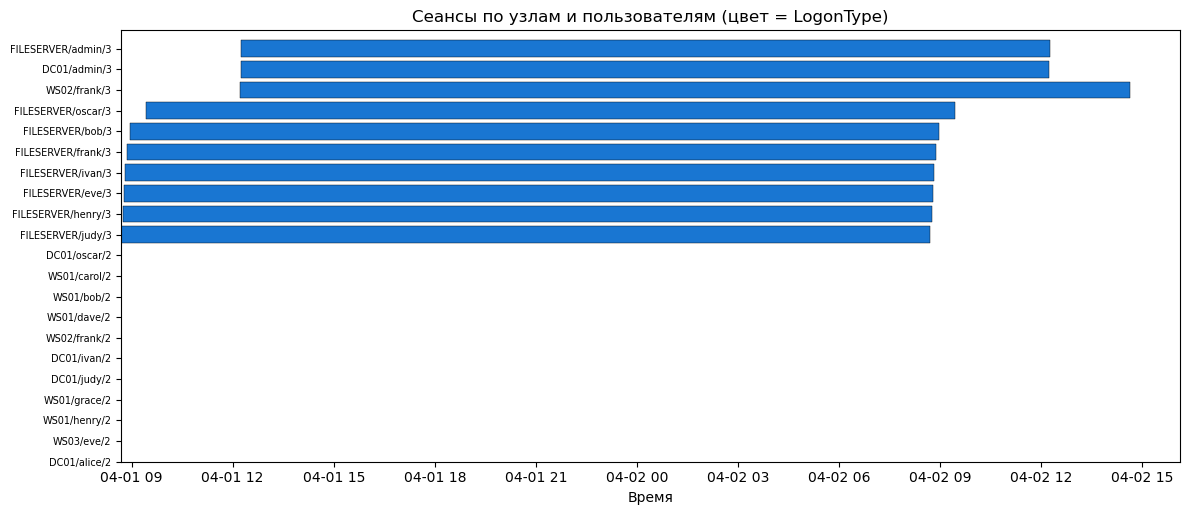

In [128]:
fig, ax = plt.subplots(figsize=(12, max(3, 0.25*len(sess_df))))
colors = {2:"#4caf50", 3:"#1976d2", 7:"#9c27b0", 10:"#ff9800"}
for i, row in sess_df[sess_df['logon_type'] == 3].iterrows():
    c = colors.get(row["logon_type"], "#888")
    ax.barh(i, max((row["ts_end"]-row["ts_start"]).total_seconds()/60, 1),
            left=row["ts_start"], color=c, edgecolor="black", linewidth=0.3)
ax.set_yticks(range(len(sess_df)))
ax.set_yticklabels([f"{r.host}/{r.user[:10]}/{r.logon_type}" for r in sess_df.itertuples()], fontsize=7)
ax.set_xlabel("Время")
ax.set_title("Сеансы по узлам и пользователям (цвет = LogonType)")
plt.tight_layout(); plt.show()

## 3. Использование метода префиксных деревьев для поиска подозрительных цепочек событий

**Идея.** Если построить дерево, в которое вложены последовательности событий «нормальных» сеансов, то его узлы запоминают вероятности перехода между событиями. Сеансы, чьи префиксы редки или отсутствуют в дереве, — кандидаты в подозрительные.

Используем последовательность EventID + имя процесса (для 4688) в качестве токенов

### 3.1. Классическое префиксное дерево на строках (демонстрация)

Прежде чем строить префиксное дерево над последовательностями событий, посмотрим на каноническую конструкцию: префиксное дерево (в англоящычной литературе часто называется trie) над набором *строк*. Каждое слово — это путь от корня по символам; общие префиксы разных слов *склеиваются* в одну ветвь, поэтому дерево компактно представляет всё множество.

Реализуем trie на базе готовой библиотеки графов **`networkx.DiGraph`**: каждый узел — это кортеж символов префикса (`()` — корень, `('c',)`, `('c','a')`, `('c','a','r')` …), каждое ребро — добавление одного символа. Узел хранит атрибут `count` — сколько раз этот префикс встретился среди вставленных слов; листовой узел дополнительно помечен флагом `terminal`.


In [129]:
import networkx as nx
import matplotlib.pyplot as plt

def build_string_trie(words):
    """Префиксное дерево на networkx.DiGraph. Узел = кортеж символов префикса."""
    G = nx.DiGraph()
    G.add_node((), count=0, terminal=False)
    for w in words:
        prefix = ()
        for ch in w:
            new_prefix = prefix + (ch,)
            if not G.has_node(new_prefix):
                G.add_node(new_prefix, count=0, terminal=False)
                G.add_edge(prefix, new_prefix, token=ch)
            G.nodes[new_prefix]["count"] += 1
            prefix = new_prefix
        G.nodes[prefix]["terminal"] = True
    return G


In [130]:
words = ["car", "card", "care", "cat", "do", "dog", "dome", "domino"]
trie = build_string_trie(words)

In [131]:
trie.nodes()

NodeView(((), ('c',), ('c', 'a'), ('c', 'a', 'r'), ('c', 'a', 'r', 'd'), ('c', 'a', 'r', 'e'), ('c', 'a', 't'), ('d',), ('d', 'o'), ('d', 'o', 'g'), ('d', 'o', 'm'), ('d', 'o', 'm', 'e'), ('d', 'o', 'm', 'i'), ('d', 'o', 'm', 'i', 'n'), ('d', 'o', 'm', 'i', 'n', 'o')))

C:\Users\ndomukhovsky\AppData\Local\Temp\ipykernel_20976\4242627546.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


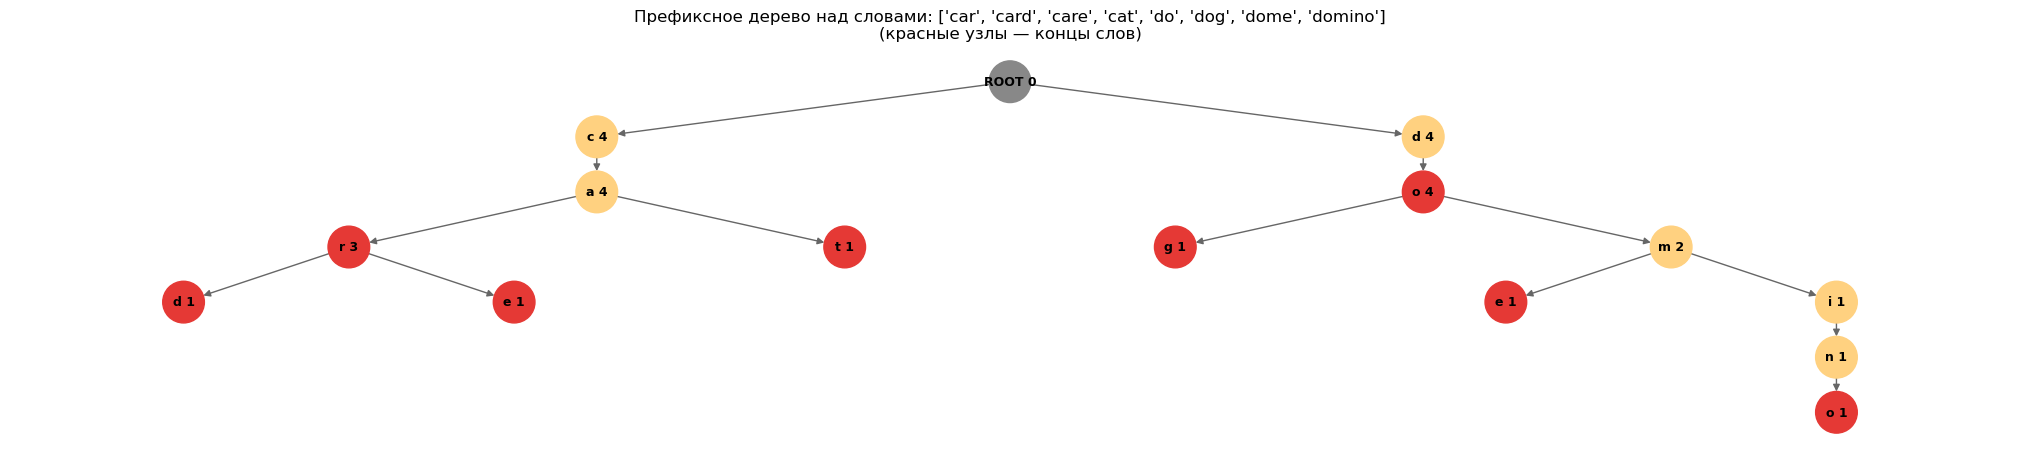

In [162]:
def hierarchy_pos(G, root=(), width=1.0, vert_gap=0.3, xcenter=0.0):
    """Иерархическая раскладка корневого дерева для визуализации в matplotlib.


    """
    pos = {}
    leaf_x = [0.0]  # счётчик: следующая x-координата листа

    def _layout(node, depth):
        children = list(G.successors(node))
        if not children:
            x = leaf_x[0]
            leaf_x[0] += width
            pos[node] = (x, -depth * vert_gap)
            return x
        xs = [_layout(ch, depth + 1) for ch in children]
        x = sum(xs) / len(xs)               # центроид по детям
        pos[node] = (x, -depth * vert_gap)
        return x

    _layout(root, 0)

    # Сдвинуть всё дерево, чтобы геометрический центр оказался в xcenter.
    all_x = [p[0] for p in pos.values()]
    if all_x:
        shift = xcenter - (min(all_x) + max(all_x)) / 2
        pos = {n: (p[0] + shift, p[1]) for n, p in pos.items()}
    return pos


# Визуализация
pos = hierarchy_pos(trie, root=(), width=4.0, vert_gap=0.45)
labels = {n: (f"ROOT {trie.nodes[n]['count']}" if n == () else n[-1] + " " + str(trie.nodes[n]['count'])) for n in trie.nodes()}
node_colors = ["#e53935" if trie.nodes[n]["terminal"]
               else ("#888" if n == () else "#ffd180")
               for n in trie.nodes()]

plt.figure(figsize=(20, 4))
nx.draw(trie, pos,
        labels=labels, node_color=node_colors,
        node_size=900, font_size=9, font_weight="bold",
        arrowsize=10, edge_color="#666")
plt.title(f"Префиксное дерево над словами: {words}\n(красные узлы — концы слов)")
plt.tight_layout(); plt.show()

### 3.2. От строк к последовательностям событий

Идея переносится один-в-один: вместо символов алфавита у нас будут **токены событий** — `EventID` или, для `4688`, `EventID:имя_процесса`. Сеанс пользователя — это «слово», и набор «нормальных» сеансов формирует trie, по узлам которого можно оценить вероятность каждого перехода и подсветить аномальные.

Для оценки вероятности будем применять меру схожую перплексии - насколько вероятна (или невероятна) вся наблюдаемая последовательность токенов. 
Для последовательности $x_1, x_2, \ldots, x_n$ мера будетт считаться так:

$$\text{NLL}(x) = \frac{1}{n} \sum_{i=1}^{n} -\log P(x_i \mid x_{i-k}, \ldots, x_{i-1})$$

где $k = \texttt{max\_depth} - 1$. То есть мы строим Марковскую модель порядка $k$ — каждый токен «зависит» только от $k$ предшествующих (иначе модель будет крайне чувствительна к любым изменениям в длинных сеансах, что слабо соответствует реальности).

Процесс вычисления вероятности $P(x_i \mid \text{ctx})$:

в дереве узел `ctx` хранит счётчик `count`, равный числу раз, когда n-грамма `ctx` встретилась в обучении. Дополнительно используется сглаживание Лапласа ($\Delta\alpha$):

$$P(x_i \mid \text{ctx}) = \frac{c(\text{ctx}, x_i) + \alpha}{c(\text{ctx}, *) + \alpha \cdot V}$$

где:

- $c(\text{ctx}, x_i)$ — счётчик `count` дочернего узла `ctx + (x_i,)`,
- $c(\text{ctx}, *)$ — сумма счётчиков `count` всех потомков узла `ctx`, то есть сколько раз контекст `ctx` встречался в принципе,
- $V$ — общий размер словаря (`len(self.vocab)`),
- $\alpha$ — параметр сглаживания (`smoothing`, в нашем примере взят равный `0.3`).

Функция сглаживания: избежать ситуации, когда незнакомый переход получал бы меру $\infty$, так как его вероятность равна 0, соответственно логарифм будет равен бесконечности

In [133]:
class PrefixTree:
    """Префиксное дерево с лапласовским сглаживанием 

    Узлы графа — кортежи токенов префиксов; корень — пустой кортеж `()`.
    Каждое ребро — расширение префикса на один токен. Атрибут `count` узла
    равен количеству раз, когда соответствующая n-грамма встречалась при обучении.
    """
    def __init__(self, max_depth=6, smoothing=0.3):
        self.max_depth = max_depth
        self.smoothing = smoothing
        self.G = nx.DiGraph()
        self.G.add_node((), count=0)
        self.vocab = set()

    def fit(self, sequences):
        for seq in sequences:
            for i in range(len(seq)):
                prefix = ()
                for tok in seq[i:i + self.max_depth]:
                    self.vocab.add(tok)
                    new_prefix = prefix + (tok,)
                    if not self.G.has_node(new_prefix):
                        self.G.add_node(new_prefix, count=0)
                        self.G.add_edge(prefix, new_prefix, token=tok)
                    self.G.nodes[new_prefix]["count"] += 1
                    prefix = new_prefix
        return self

    def _ctx_node(self, ctx):
        ctx = tuple(ctx)
        return ctx if self.G.has_node(ctx) else None

    def neg_log_prob(self, seq):
        if not seq:
            return 0.0
        total, cnt = 0.0, 0
        V = max(len(self.vocab), 1)
        for i, tok in enumerate(seq):
            ctx = tuple(seq[max(0, i - self.max_depth + 1):i])
            node = self._ctx_node(ctx)
            if node is not None:
                ctx_total = sum(self.G.nodes[c]["count"] for c in self.G.successors(node))
                child = node + (tok,)
                tok_count = self.G.nodes[child]["count"] if self.G.has_node(child) else 0
                p = (tok_count + self.smoothing) / (ctx_total + self.smoothing * V)
            else:
                p = self.smoothing / (self.smoothing * V)
            total += -math.log(max(p, 1e-12))
            cnt += 1
        return total / cnt




In [139]:
def session_to_tokens(row):
    out = []
    for eid, p in zip(row["event_seq"], row["process_seq"]):
        if eid == 4688 and p:
            base = str(p).replace("\\", "/").rsplit("/", 1)[-1].lower()
            out.append(f"4688:{base}")
        else:
            out.append(str(eid))
    return out

In [140]:
sess_df["tokens"] = sess_df.apply(session_to_tokens, axis=1)

In [141]:
sess_df["len"] = sess_df["tokens"].apply(len)
sess_df.head(3)[["host","user","logon_type","len","tokens"]]

,host,user,logon_type,len,tokens
0,DC01,alice,2,8,"[4624, 4672, 4688:notepad.exe, 4688:notepad.ex..."
1,WS03,eve,2,9,"[4624, 4672, 4688:notepad.exe, 4688:7zfm.exe, ..."
2,WS01,henry,2,8,"[4624, 4672, 4688:explorer.exe, 4688:7zfm.exe,..."


In [142]:
#формируем обучающую выборку из сеансов, длина которых попадает в 80% перцентиль + все они с интерактивным входом 
train_mask = (sess_df["len"] <= sess_df["len"].quantile(0.8)) & (sess_df["logon_type"] == 2)
#train_mask = sess_df["len"] <= sess_df["len"].quantile(0.8)
train_seqs = sess_df.loc[train_mask, "tokens"].tolist()
print(f"Обучаемся на {len(train_seqs)} «нормальных» сеансах (LogonType=2, верхний 80-й перцентиль длины)")

Обучаемся на 8 «нормальных» сеансах (LogonType=2, верхний 80-й перцентиль длины)


In [143]:
train_seqs

[['4624',
  '4672',
  '4688:notepad.exe',
  '4688:notepad.exe',
  '4688:7zfm.exe',
  '4688:chrome.exe',
  '4688:chrome.exe',
  '4634'],
 ['4624',
  '4672',
  '4688:notepad.exe',
  '4688:7zfm.exe',
  '4688:7zfm.exe',
  '4688:excel.exe',
  '4688:explorer.exe',
  '4688:chrome.exe',
  '4634'],
 ['4624',
  '4672',
  '4688:explorer.exe',
  '4688:7zfm.exe',
  '4688:excel.exe',
  '4688:chrome.exe',
  '4688:7zfm.exe',
  '4634'],
 ['4624',
  '4672',
  '4688:notepad.exe',
  '4688:explorer.exe',
  '4688:explorer.exe',
  '4688:notepad.exe',
  '4634'],
 ['4624',
  '4672',
  '4688:chrome.exe',
  '4688:explorer.exe',
  '4688:notepad.exe',
  '4688:explorer.exe',
  '4688:explorer.exe',
  '4688:outlook.exe',
  '4634'],
 ['4624',
  '4672',
  '4688:explorer.exe',
  '4688:excel.exe',
  '4688:explorer.exe',
  '4688:notepad.exe',
  '4634'],
 ['4624',
  '4672',
  '4688:notepad.exe',
  '4688:explorer.exe',
  '4688:notepad.exe',
  '4688:chrome.exe',
  '4688:notepad.exe',
  '4688:7zfm.exe',
  '4634'],
 ['4624',
 

In [167]:
tree = PrefixTree(max_depth=9, smoothing=0.001).fit(train_seqs)
print(f"Размер дерева: {tree.G.number_of_nodes()} узлов, {tree.G.number_of_edges()} рёбер; |vocab|={len(tree.vocab)}")

Размер дерева: 218 узлов, 217 рёбер; |vocab|=9


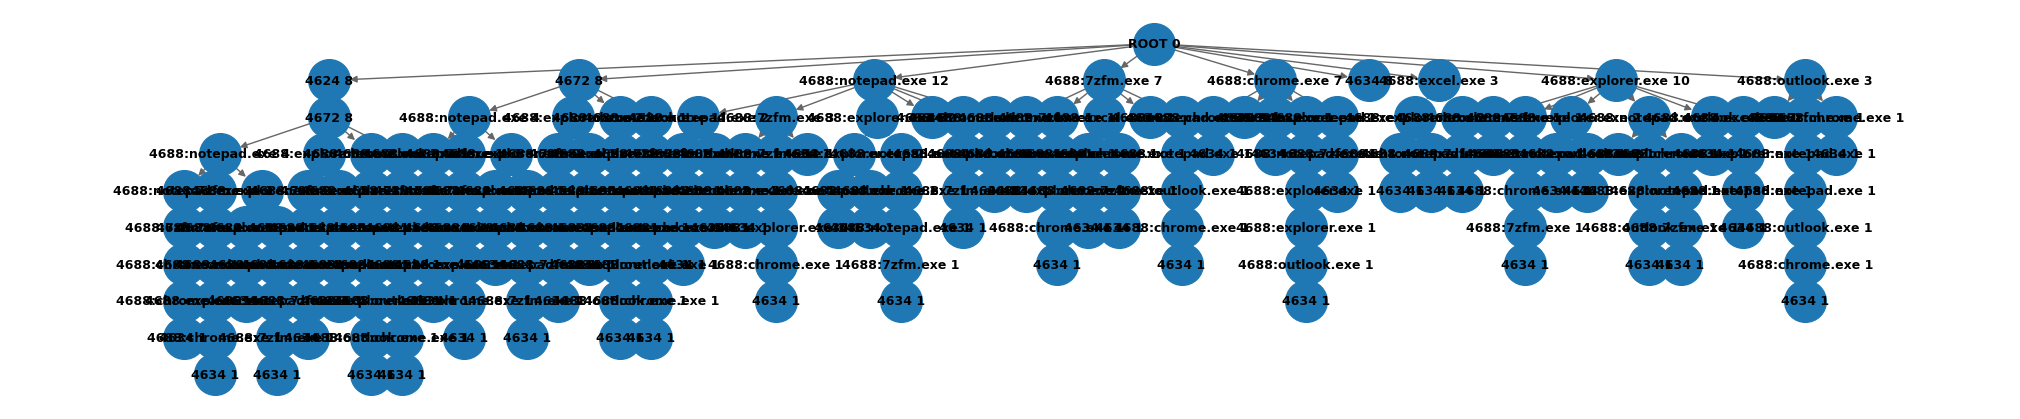

In [168]:
pos = hierarchy_pos(tree.G, root=(), width=2.0, vert_gap=0.45)
labels = {n: (f"ROOT {tree.G.nodes[n]['count']}" if n == () else n[-1] + " " + str(tree.G.nodes[n]['count'])) for n in tree.G.nodes()}
#node_colors = ["#e53935" if tree.G.nodes[n]["terminal"]
#               else ("#888" if n == () else "#ffd180")
#               for n in tree.G.nodes()]

plt.figure(figsize=(20, 4))
nx.draw(tree.G, pos,
        labels=labels,
        node_size=900, font_size=9, font_weight="bold",
        arrowsize=10, edge_color="#666")
plt.show()

In [169]:
sess_df["nll"] = sess_df["tokens"].apply(tree.neg_log_prob)
top = sess_df.sort_values("nll", ascending=False)
top[["host","user","logon_type","src_ip","len","nll","session_key"]]

,host,user,logon_type,src_ip,len,nll,session_key
16,FILESERVER,bob,3,10.0.4.26,2,5.549273,"(FILESERVER, 0xb46ed1f)"
17,FILESERVER,oscar,3,10.0.5.22,2,5.549273,"(FILESERVER, 0x36a147e)"
20,FILESERVER,admin,3,10.0.1.50,2,5.549273,"(FILESERVER, 0xd13dbc9)"
12,FILESERVER,henry,3,10.0.4.208,2,5.549273,"(FILESERVER, 0xfc02405)"
11,FILESERVER,judy,3,10.0.2.77,2,5.549273,"(FILESERVER, 0xda5bd9c)"
14,FILESERVER,ivan,3,10.0.2.110,2,5.549273,"(FILESERVER, 0x7b4a4e3)"
15,FILESERVER,frank,3,10.0.5.84,2,5.549273,"(FILESERVER, 0x7c79dee)"
13,FILESERVER,eve,3,10.0.5.121,2,5.549273,"(FILESERVER, 0xf43d47c)"
19,DC01,admin,3,10.0.1.50,5,3.098799,"(DC01, 0xab09153)"
18,WS02,frank,3,203.0.113.66,8,2.760709,"(WS02, 0x21f8ac6)"


In [151]:
df[df["session_key"] == ("WS01", "0x5314317")]

,ts,host,channel,event_id,raw_message,target_user,target_domain,target_logon_id,subject_user,subject_logon_id,logon_type,src_ip,workstation,logon_guid,process_name,cmdline,parent_process,privileges,object_name,access_mask,sub_status,member_name,group_name,session_key,process_base
34,2026-04-01 08:21:00+00:00,WS01,Security,4624,An account was successfully logged on.\nSubjec...,dave,CORP,0x5314317,-,0x0,2.0,10.0.1.56,WS01,{C6A7EE39-7545-106F-A183-891566B2BC5B},None,None,None,None,None,None,None,None,None,"(WS01, 0x5314317)",-
35,2026-04-01 08:21:02+00:00,WS01,Security,4672,Special privileges assigned to new logon.\n A...,None,None,None,dave,0x5314317,NaN,None,None,None,None,None,None,SeAuditPrivilege,None,None,None,None,None,"(WS01, 0x5314317)",-
46,2026-04-01 08:26:00+00:00,WS01,Security,4688,A new process has been created.\nCreator Subje...,None,None,None,dave,0x5314317,NaN,None,None,None,C:\Program Files\Microsoft Office\root\Office1...,EXCEL.EXE report.xlsx,C:\Windows\explorer.exe,None,None,None,None,None,None,"(WS01, 0x5314317)",excel.exe
55,2026-04-01 08:30:07+00:00,WS01,Security,4688,A new process has been created.\nCreator Subje...,None,None,None,dave,0x5314317,NaN,None,None,None,C:\Program Files\7-Zip\7zFM.exe,7zFM.exe,C:\Windows\explorer.exe,None,None,None,None,None,None,"(WS01, 0x5314317)",7zfm.exe
68,2026-04-01 08:39:08+00:00,WS01,Security,4688,A new process has been created.\nCreator Subje...,None,None,None,dave,0x5314317,NaN,None,None,None,C:\Program Files\Google\Chrome\Application\chr...,chrome.exe --profile-directory=Default,C:\Windows\explorer.exe,None,None,None,None,None,None,"(WS01, 0x5314317)",chrome.exe
80,2026-04-01 08:47:27+00:00,WS01,Security,4688,A new process has been created.\nCreator Subje...,None,None,None,dave,0x5314317,NaN,None,None,None,C:\Program Files\Microsoft Office\root\Office1...,OUTLOOK.EXE -profile Default,C:\Windows\explorer.exe,None,None,None,None,None,None,"(WS01, 0x5314317)",outlook.exe
88,2026-04-01 08:52:28+00:00,WS01,Security,4688,A new process has been created.\nCreator Subje...,None,None,None,dave,0x5314317,NaN,None,None,None,C:\Program Files\Microsoft Office\root\Office1...,OUTLOOK.EXE -profile Default,C:\Windows\explorer.exe,None,None,None,None,None,None,"(WS01, 0x5314317)",outlook.exe
92,2026-04-01 08:57:10+00:00,WS01,Security,4688,A new process has been created.\nCreator Subje...,None,None,None,dave,0x5314317,NaN,None,None,None,C:\Program Files\7-Zip\7zFM.exe,7zFM.exe,C:\Windows\explorer.exe,None,None,None,None,None,None,"(WS01, 0x5314317)",7zfm.exe
95,2026-04-01 09:06:51+00:00,WS01,Security,4688,A new process has been created.\nCreator Subje...,None,None,None,dave,0x5314317,NaN,None,None,None,C:\Program Files\Microsoft Office\root\Office1...,EXCEL.EXE report.xlsx,C:\Windows\explorer.exe,None,None,None,None,None,None,"(WS01, 0x5314317)",excel.exe
99,2026-04-01 09:14:39+00:00,WS01,Security,4688,A new process has been created.\nCreator Subje...,None,None,None,dave,0x5314317,NaN,None,None,None,C:\Windows\System32\notepad.exe,notepad.exe note.txt,C:\Windows\explorer.exe,None,None,None,None,None,None,"(WS01, 0x5314317)",notepad.exe


In [170]:
def anomalous_prefixes(seq, tree, top=5, ctx=3):
    out = []
    V = max(len(tree.vocab), 1)
    for i, tok in enumerate(seq):
        ctx_seq = tuple(seq[max(0, i - ctx):i])
        node = tree._ctx_node(ctx_seq)
        if node is not None:
            ctx_total = sum(tree.G.nodes[c]["count"] for c in tree.G.successors(node))
            child = node + (tok,)
            tok_count = tree.G.nodes[child]["count"] if tree.G.has_node(child) else 0
            p = (tok_count + tree.smoothing) / (ctx_total + tree.smoothing * V)
        else:
            p = tree.smoothing / (tree.smoothing * V)
        out.append((-math.log(max(p, 1e-12)), " → ".join(list(ctx_seq) + [tok])))
    out.sort(reverse=True)
    return out[:top]

worst = sess_df.sort_values("nll", ascending=False).iloc[9]
print(f"Наиболее аномальный сеанс: {worst['host']}/{worst['user']} (NLL={worst['nll']:.2f})")
print("Топ-редкие переходы:")
for nll, path in anomalous_prefixes(worst["tokens"], tree):
    print(f"  -log p = {nll:5.2f}   {path}")


Наиболее аномальный сеанс: WS02/frank (NLL=2.76)
Топ-редкие переходы:
  -log p =  8.99   4624 → 4672 → 4688:cmd.exe
  -log p =  2.20   4688:powershell.exe → 4688:net.exe → 4688:net.exe → 4688:ipconfig.exe
  -log p =  2.20   4688:net.exe → 4688:net.exe → 4688:ipconfig.exe → 4688:mimikatz.exe
  -log p =  2.20   4688:cmd.exe → 4688:powershell.exe → 4688:net.exe → 4688:net.exe
  -log p =  2.20   4672 → 4688:cmd.exe → 4688:powershell.exe → 4688:net.exe


In [171]:
sess_df.sort_values("nll", ascending=False)

,session_key,host,logon_id,user,logon_type,src_ip,logon_guid,ts_start,ts_end,duration_s,n_events,event_seq,process_seq,tokens,len,nll
16,"(FILESERVER, 0xb46ed1f)",FILESERVER,0xb46ed1f,bob,3,10.0.4.26,{571AA876-4F9B-6E3D-AC56-2F7C1A2A73ED},2026-04-01 08:56:57+00:00,2026-04-01 08:57:07+00:00,10.0,2,"[4624, 4634]","[-, -]","[4624, 4634]",2,5.549273
17,"(FILESERVER, 0x36a147e)",FILESERVER,0x36a147e,oscar,3,10.0.5.22,{2F923996-22CB-786C-CEBB-145998326856},2026-04-01 09:25:19+00:00,2026-04-01 09:25:29+00:00,10.0,2,"[4624, 4634]","[-, -]","[4624, 4634]",2,5.549273
20,"(FILESERVER, 0xd13dbc9)",FILESERVER,0xd13dbc9,admin,3,10.0.1.50,{EEEA163E-2338-7D12-BD32-50C448F4EF12},2026-04-01 12:14:49+00:00,2026-04-01 12:14:53+00:00,4.0,2,"[4624, 4663]","[-, -]","[4624, 4663]",2,5.549273
12,"(FILESERVER, 0xfc02405)",FILESERVER,0xfc02405,henry,3,10.0.4.208,{5496F63C-79DB-8E94-F888-7C6A7900F7F9},2026-04-01 08:44:36+00:00,2026-04-01 08:44:46+00:00,10.0,2,"[4624, 4634]","[-, -]","[4624, 4634]",2,5.549273
11,"(FILESERVER, 0xda5bd9c)",FILESERVER,0xda5bd9c,judy,3,10.0.2.77,{63F2AE24-E8F6-920C-D894-4F417C967F79},2026-04-01 08:41:35+00:00,2026-04-01 08:41:45+00:00,10.0,2,"[4624, 4634]","[-, -]","[4624, 4634]",2,5.549273
14,"(FILESERVER, 0x7b4a4e3)",FILESERVER,0x7b4a4e3,ivan,3,10.0.2.110,{DC96925E-7F4F-6218-6163-E5B0894A05E4},2026-04-01 08:48:06+00:00,2026-04-01 08:48:16+00:00,10.0,2,"[4624, 4634]","[-, -]","[4624, 4634]",2,5.549273
15,"(FILESERVER, 0x7c79dee)",FILESERVER,0x7c79dee,frank,3,10.0.5.84,{E9A1FA6F-98CD-65D7-4E40-004AEB2263DD},2026-04-01 08:51:42+00:00,2026-04-01 08:51:52+00:00,10.0,2,"[4624, 4634]","[-, -]","[4624, 4634]",2,5.549273
13,"(FILESERVER, 0xf43d47c)",FILESERVER,0xf43d47c,eve,3,10.0.5.121,{1C11F735-51E9-D825-2086-C36362801C45},2026-04-01 08:46:46+00:00,2026-04-01 08:46:56+00:00,10.0,2,"[4624, 4634]","[-, -]","[4624, 4634]",2,5.549273
19,"(DC01, 0xab09153)",DC01,0xab09153,admin,3,10.0.1.50,{EEEA163E-2338-7D12-BD32-50C448F4EF12},2026-04-01 12:14:14+00:00,2026-04-01 12:14:31+00:00,17.0,5,"[4624, 4672, 4688, 4720, 4732]","[-, -, C:\Windows\System32\ntdsutil.exe, -, -]","[4624, 4672, 4688:ntdsutil.exe, 4720, 4732]",5,3.098799
18,"(WS02, 0x21f8ac6)",WS02,0x21f8ac6,frank,3,203.0.113.66,{EEEA163E-2338-7D12-BD32-50C448F4EF12},2026-04-01 12:13:00+00:00,2026-04-01 12:14:06+00:00,66.0,8,"[4624, 4672, 4688, 4688, 4688, 4688, 4688, 4688]","[-, -, C:\Windows\System32\cmd.exe, C:\Windows...","[4624, 4672, 4688:cmd.exe, 4688:powershell.exe...",8,2.760709


C:\Users\ndomukhovsky\AppData\Local\Temp\ipykernel_20976\2079410021.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.title("Граф переходов в подозрительном сеансе"); plt.tight_layout(); plt.show()


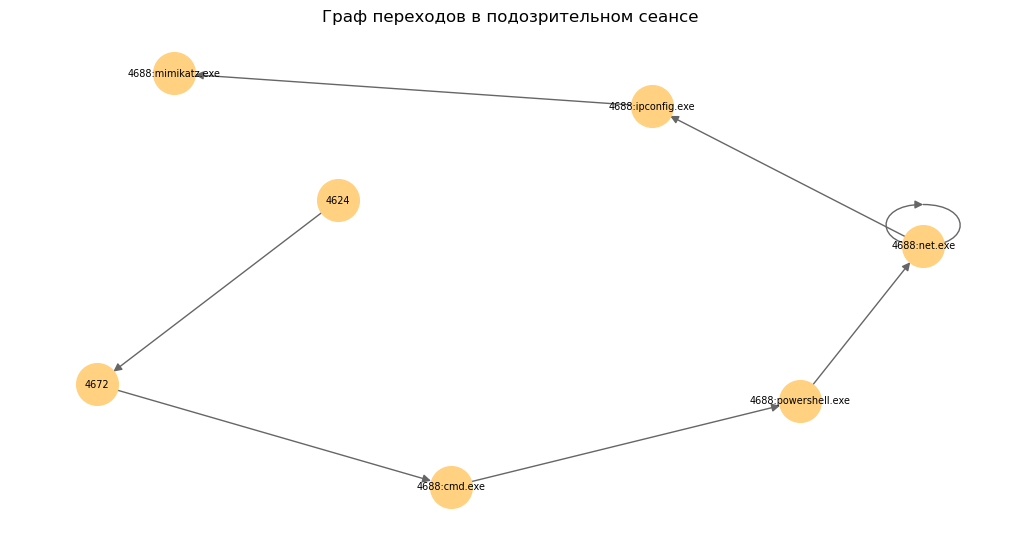

In [172]:
def plot_session_tree(seq, max_nodes=25):
    G = nx.DiGraph()
    for i in range(len(seq)-1):
        a, b = seq[i], seq[i+1]
        if a not in G: G.add_node(a)
        if b not in G: G.add_node(b)
        if G.has_edge(a, b):
            G[a][b]["weight"] += 1
        else:
            G.add_edge(a, b, weight=1)
        if len(G.nodes) >= max_nodes: break
    pos = nx.spring_layout(G, seed=1, k=1.2)
    plt.figure(figsize=(10,5))
    nx.draw(G, pos, with_labels=True, node_size=900, node_color="#ffd180",
            font_size=7, arrowsize=12, edge_color="#666")
    plt.title("Граф переходов в подозрительном сеансе"); plt.tight_layout(); plt.show()

plot_session_tree(worst["tokens"])


## 4. Выполнение задачи наблюдения за пользователем (Identity tracking): построение расширенного сеанса пользователя за пределами одного узла

В рамках одного хоста сеанс задаётся `(host, logon_id)`. Но реальный пользователь часто переходит между узлами: интерактивно зашёл на WS01, оттуда — сетевой сеанс на FILESERVER, затем remote-interactive на DC01. Чтобы построить **расширенный сеанс**, нужно склеить локальные сеансы по нескольким сигналам.

Сигналы склейки (в порядке убывания надёжности):

1. Совпадение **`LogonGUID`** — Windows проставляет один и тот же GUID для связных логонов в рамках одной Kerberos TGT-сессии.
2. Совпадение `(account, src_ip)` и пересечение по времени.
3. Цепочка: `host_A` устанавливает сетевой сеанс на `host_B` ⇒ `IpAddress` сеанса на `host_B` совпадает с одним из IP-адресов `host_A`.

Реализуем построение Системы непересекающихся множеств (DSU) по всем локальным сеансам с этими правилами слияния. Используем готовую  реализацию **`networkx.utils.UnionFind`** — она поддерживает path compression и union by rank, имеет компактный API: `uf[x]` возвращает представителя множества (find), `uf.union(*items)` объединяет произвольное число элементов в одно множество, `uf.to_sets()` итерирует по компонентам.

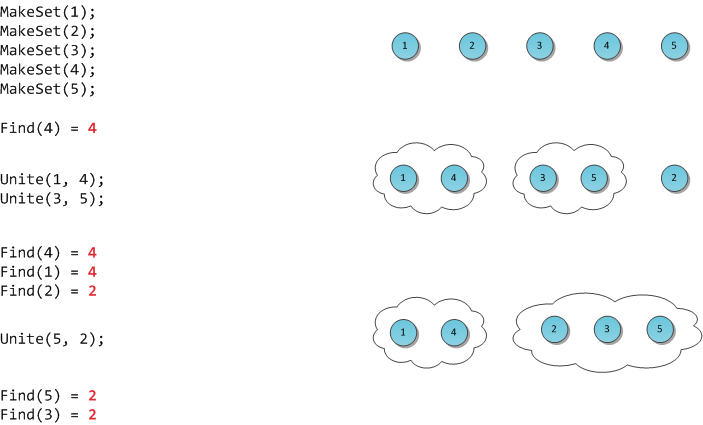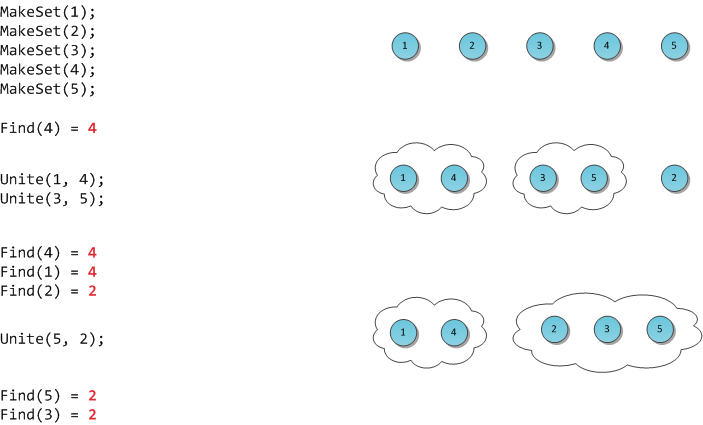

In [173]:
from networkx.utils import UnionFind
uf = UnionFind(sess_df.index)

In [174]:
# Правило A — общий LogonGUID
guid_to_idx = defaultdict(list)
for i, r in sess_df.iterrows():
    if r["logon_guid"] and r["logon_guid"] != "-":
        guid_to_idx[r["logon_guid"]].append(i)

In [175]:
guid_to_idx

defaultdict(list,
            {'{46685257-7248-4771-347A-10456C031199}': [0],
             '{1C11F735-51E9-D825-2086-C36362801C45}': [1, 13],
             '{5496F63C-79DB-8E94-F888-7C6A7900F7F9}': [2, 12],
             '{8CBFEDB0-87B5-D8A5-6C70-66FDB09B2A5C}': [3],
             '{63F2AE24-E8F6-920C-D894-4F417C967F79}': [4, 11],
             '{DC96925E-7F4F-6218-6163-E5B0894A05E4}': [5, 14],
             '{E9A1FA6F-98CD-65D7-4E40-004AEB2263DD}': [6, 15],
             '{C6A7EE39-7545-106F-A183-891566B2BC5B}': [7],
             '{571AA876-4F9B-6E3D-AC56-2F7C1A2A73ED}': [8, 16],
             '{FC377A4C-7730-33B6-C29F-E82547294739}': [9],
             '{2F923996-22CB-786C-CEBB-145998326856}': [10, 17],
             '{EEEA163E-2338-7D12-BD32-50C448F4EF12}': [18, 19, 20]})

In [178]:
joined_guid = 0
for g, ix in guid_to_idx.items():
    for j in ix[1:]:
        if uf[ix[0]] != uf[j]:
            uf.union(ix[0], j) 
            joined_guid += 1

In [179]:
# Правило B — (account, src_ip) с временным пересечением ±15 мин
joined_acct = 0
for u, g in sess_df.groupby("user"):
    g = g.sort_values("ts_start")
    rows = list(g.itertuples())
    for i in range(len(rows)):
        for j in range(i + 1, len(rows)):
            if rows[j].ts_start - rows[i].ts_end > pd.Timedelta(minutes=15):
                break
            if rows[i].src_ip and rows[i].src_ip == rows[j].src_ip and rows[i].src_ip != "-":
                if uf[rows[i].Index] != uf[rows[j].Index]:
                    uf.union(rows[i].Index, rows[j].Index)
                    joined_acct += 1

In [180]:
# Правило C — host_A инициировал сетевой логон на host_B
host_ips = sess_df.groupby("host")["src_ip"].apply(
    lambda s: set(x for x in s.dropna() if x != "-")).to_dict()

In [181]:
host_ips

{'DC01': {'10.0.1.25', '10.0.1.50', '10.0.2.110', '10.0.2.77', '10.0.5.22'},
 'FILESERVER': {'10.0.1.50',
  '10.0.2.110',
  '10.0.2.77',
  '10.0.4.208',
  '10.0.4.26',
  '10.0.5.121',
  '10.0.5.22',
  '10.0.5.84'},
 'WS01': {'10.0.1.56', '10.0.3.104', '10.0.3.43', '10.0.4.208', '10.0.4.26'},
 'WS02': {'10.0.5.84', '203.0.113.66'},
 'WS03': {'10.0.5.121'}}

In [182]:
joined_pivot = 0
for j, r in sess_df[sess_df["logon_type"] == 3].iterrows():
    if r["src_ip"] and r["src_ip"] != "-":
        for h, ips in host_ips.items():
            if h == r["host"]: continue
            if r["src_ip"] in ips:
                cand = sess_df[(sess_df["host"] == h) & (sess_df["src_ip"] == r["src_ip"])]
                cand = cand[(cand["ts_start"] <= r["ts_start"]) &
                            (cand["ts_end"] >= r["ts_start"] - pd.Timedelta(minutes=30))]
                if len(cand) and uf[j] != uf[cand.index[0]]:
                    uf.union(j, cand.index[0])
                    joined_pivot += 1




In [183]:
print(f"Слияний по LogonGUID: {joined_guid}; по (account,src_ip): {joined_acct}; по pivot: {joined_pivot}")

# uf[i] возвращает «представителя» множества — используем его как идентификатор расширенного сеанса
sess_df["identity_id"] = [uf[i] for i in sess_df.index]
print(f"Расширенных идентичностей: {sess_df['identity_id'].nunique()}; локальных сеансов: {len(sess_df)}")

Слияний по LogonGUID: 9; по (account,src_ip): 0; по pivot: 0
Расширенных идентичностей: 12; локальных сеансов: 21


In [184]:
extended = (sess_df.groupby("identity_id")
              .agg(users=("user", lambda s: sorted(set(s))),
                   hosts=("host", lambda s: sorted(set(s))),
                   logon_types=("logon_type", lambda s: sorted({int(x) for x in s if pd.notna(x)})),
                   ts_min=("ts_start","min"), ts_max=("ts_end","max"),
                   n_local=("identity_id","count"))
              .reset_index())
extended["span_s"] = (extended["ts_max"] - extended["ts_min"]).dt.total_seconds()
extended["multi_host"] = extended["hosts"].apply(len) > 1
extended.sort_values(["multi_host","n_local"], ascending=[False, False]).head(10)

,identity_id,users,hosts,logon_types,ts_min,ts_max,n_local,span_s,multi_host
11,18,"[admin, frank]","[DC01, FILESERVER, WS02]",[3],2026-04-01 12:13:00+00:00,2026-04-01 12:14:53+00:00,3,113.0,True
1,1,[eve],"[FILESERVER, WS03]","[2, 3]",2026-04-01 08:02:00+00:00,2026-04-01 14:34:46+00:00,2,23566.0,True
2,2,[henry],"[FILESERVER, WS01]","[2, 3]",2026-04-01 08:02:00+00:00,2026-04-01 09:33:36+00:00,2,5496.0,True
4,5,[ivan],"[DC01, FILESERVER]","[2, 3]",2026-04-01 08:12:00+00:00,2026-04-01 12:44:06+00:00,2,16326.0,True
5,6,[frank],"[FILESERVER, WS02]","[2, 3]",2026-04-01 08:16:00+00:00,2026-04-01 09:37:42+00:00,2,4902.0,True
7,8,[bob],"[FILESERVER, WS01]","[2, 3]",2026-04-01 08:22:00+00:00,2026-04-01 09:54:57+00:00,2,5577.0,True
9,11,[judy],"[DC01, FILESERVER]","[2, 3]",2026-04-01 08:05:00+00:00,2026-04-01 10:32:35+00:00,2,8855.0,True
10,17,[oscar],"[DC01, FILESERVER]","[2, 3]",2026-04-01 08:30:00+00:00,2026-04-01 12:16:19+00:00,2,13579.0,True
0,0,[alice],[DC01],[2],2026-04-01 08:00:00+00:00,2026-04-01 09:26:07+00:00,1,5167.0,False
3,3,[grace],[WS01],[2],2026-04-01 08:04:00+00:00,2026-04-01 09:38:15+00:00,1,5655.0,False


## 5. Использование обогащения событий (на примере GeoIP) и применение графовых представлений для поиска аномальных цепочек событий

### 5.1. GeoIP

Полноценный MaxMind GeoLite2 требует регистрации, поэтому мы используем "заглушку" на основе диапазонов RFC и нескольких публичных подсетей (этого достаточно для иллюстрации идеи; в боевом режиме нужно заменять на API сервиса geo IP).

Аномалия GeoIP — это сеанс пользователя `u` с IP, чья страна или ASN не входят в типичный для `u` профиль.

In [185]:
import ipaddress

GEO_TABLE = [
    ("10.0.0.0/8",        "INTERNAL", "CORP-LAN"),
    ("172.16.0.0/12",     "INTERNAL", "CORP-LAN"),
    ("192.168.0.0/16",    "INTERNAL", "CORP-LAN"),
    ("203.0.113.0/24",    "TK",       "AS-EVIL"),
    ("198.51.100.0/24",   "DE",       "AS-PARTNER"),
    ("8.8.8.0/24",        "US",       "GOOGLE"),
    ("1.1.1.0/24",        "US",       "CLOUDFLARE"),
]
GEO_NETS = [(ipaddress.ip_network(n), c, a) for n, c, a in GEO_TABLE]

def geoip_lookup(ip):
    if not ip or ip == "-": return ("UNKNOWN","UNKNOWN")
    try:
        ip_obj = ipaddress.ip_address(ip)
    except ValueError:
        return ("UNKNOWN","UNKNOWN")
    for net, country, asn in GEO_NETS:
        if ip_obj in net:
            return (country, asn)
    return ("FOREIGN","UNKNOWN-ASN")

sess_df[["country","asn"]] = sess_df["src_ip"].apply(lambda x: pd.Series(geoip_lookup(x)))
print("Сеансы по странам/ASN:")
print(sess_df.groupby(["country","asn"]).size().sort_values(ascending=False).to_string())

Сеансы по странам/ASN:
country   asn     
INTERNAL  CORP-LAN    20
TK        AS-EVIL      1


In [186]:
sess_df[sess_df['asn'] == "AS-EVIL"]

,session_key,host,logon_id,user,logon_type,src_ip,logon_guid,ts_start,ts_end,duration_s,n_events,event_seq,process_seq,tokens,len,nll,identity_id,country,asn
18,"(WS02, 0x21f8ac6)",WS02,0x21f8ac6,frank,3,203.0.113.66,{EEEA163E-2338-7D12-BD32-50C448F4EF12},2026-04-01 12:13:00+00:00,2026-04-01 12:14:06+00:00,66.0,8,"[4624, 4672, 4688, 4688, 4688, 4688, 4688, 4688]","[-, -, C:\Windows\System32\cmd.exe, C:\Windows...","[4624, 4672, 4688:cmd.exe, 4688:powershell.exe...",8,2.760709,18,TK,AS-EVIL


In [187]:
user_country_profile = (sess_df.groupby("user")["country"]
                        .agg(lambda s: Counter(s)).to_dict())
user_country_profile

{'admin': Counter({'INTERNAL': 2}),
 'alice': Counter({'INTERNAL': 1}),
 'bob': Counter({'INTERNAL': 2}),
 'carol': Counter({'INTERNAL': 1}),
 'dave': Counter({'INTERNAL': 1}),
 'eve': Counter({'INTERNAL': 2}),
 'frank': Counter({'INTERNAL': 2, 'TK': 1}),
 'grace': Counter({'INTERNAL': 1}),
 'henry': Counter({'INTERNAL': 2}),
 'ivan': Counter({'INTERNAL': 2}),
 'judy': Counter({'INTERNAL': 2}),
 'oscar': Counter({'INTERNAL': 2})}

In [188]:

def geo_anomaly(row, top_n=2):
    prof = user_country_profile.get(row["user"], Counter())
    if not prof: return False
    top = {c for c,_ in prof.most_common(top_n)}
    return row["country"] not in top

sess_df["geo_anomaly"] = sess_df.apply(geo_anomaly, axis=1)
geo_alerts = sess_df[sess_df["geo_anomaly"]][["host","user","logon_type","src_ip","country","asn","ts_start"]]
print("Сеансы с GeoIP-аномалией:")
geo_alerts

Сеансы с GeoIP-аномалией:


,host,user,logon_type,src_ip,country,asn,ts_start


### 5.2. Графовые методы: эмбеддинги и поиск аномальных подграфов

Строим взвешенный гиперграф взаимодействий: вершины — сущности (`user:`, `host:`, `ip:`, `proc:`), рёбра — связи в событиях (логоны, запуски процессов, доступ к файлам). Затем считаем структурные эмбеддинги вершин и применяем `IsolationForest` для поиска вершин, чья соседская структура необычна.

В качестве эмбеддингов используем простой и быстрый набор структурных признаков (степень, кластеризация, разнообразие соседей по типам). Это сильное упрощение, которое не подойдет для серьезных задач анализа - там рекомендуется применять специализированные модели для графовых эмбеддингов

In [189]:
def build_security_graph(df, sess_df):
    G = nx.MultiDiGraph()
    for _, r in sess_df.iterrows():
        u = f"user:{r['user']}" 
        h = f"host:{r['host']}"
        ip = f"ip:{r['src_ip']}" if r["src_ip"] and r["src_ip"] != "-" else None
        G.add_node(u, kind="user") 
        G.add_node(h, kind="host")
        G.add_edge(u, h, etype="logon", logon_type=r["logon_type"], country=r["country"])
        if ip:
            G.add_node(ip, kind="ip", country=r["country"], asn=r["asn"])
            G.add_edge(ip, u, etype="from_ip")
    for _, r in df[df["event_id"] == 4688].dropna(subset=["process_name"]).iterrows():
        u = f"user:{r['subject_user']}"
        p = f"proc:{Path(str(r['process_name'])).name.lower()}"
        G.add_node(u, kind="user"); G.add_node(p, kind="proc")
        G.add_edge(u, p, etype="exec")
    return G

G = build_security_graph(df, sess_df)
print(f"Граф: |V|={G.number_of_nodes()}, |E|={G.number_of_edges()}")
kinds = Counter(d.get("kind","?") for _, d in G.nodes(data=True))
print("Типы вершин:", dict(kinds))

Граф: |V|=42, |E|=116
Типы вершин: {'user': 12, 'host': 5, 'ip': 13, 'proc': 12}


In [190]:
from sklearn.ensemble import IsolationForest
G_simple = nx.Graph(G)

def node_features(node):
    deg = G_simple.degree(node)
    nb_kinds = Counter(G_simple.nodes[n].get("kind","?") for n in G_simple.neighbors(node))
    cl = nx.clustering(G_simple, node) if deg > 1 else 0.0
    out_logons = sum(1 for _,_,d in G.out_edges(node, data=True) if d.get("etype")=="logon")
    proc_div = sum(1 for n in G_simple.neighbors(node) if G_simple.nodes[n].get("kind")=="proc")
    ip_div = sum(1 for n in G_simple.neighbors(node) if G_simple.nodes[n].get("kind")=="ip")
    return [deg, cl, out_logons, proc_div, ip_div, nb_kinds.get("user",0), nb_kinds.get("host",0)]

nodes = list(G.nodes())
X = np.array([node_features(n) for n in nodes])
iso = IsolationForest(contamination=0.08,).fit(X)

scores = -iso.score_samples(X)
node_scores = pd.DataFrame({"node": nodes, "kind":[G.nodes[n].get("kind") for n in nodes], "score": scores})
print("Топ-аномальных вершин графа:")
node_scores.sort_values("score", ascending=False)

Топ-аномальных вершин графа:


,node,kind,score
15,user:frank,user,0.781327
30,proc:notepad.exe,proc,0.675742
28,user:admin,user,0.619017
24,user:oscar,user,0.605606
0,user:alice,user,0.604694
18,user:dave,user,0.602840
34,proc:excel.exe,proc,0.574937
11,user:judy,user,0.569290
32,proc:7zfm.exe,proc,0.566188
3,user:eve,user,0.546941


C:\Users\ndomukhovsky\AppData\Local\Temp\ipykernel_20976\3118525821.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


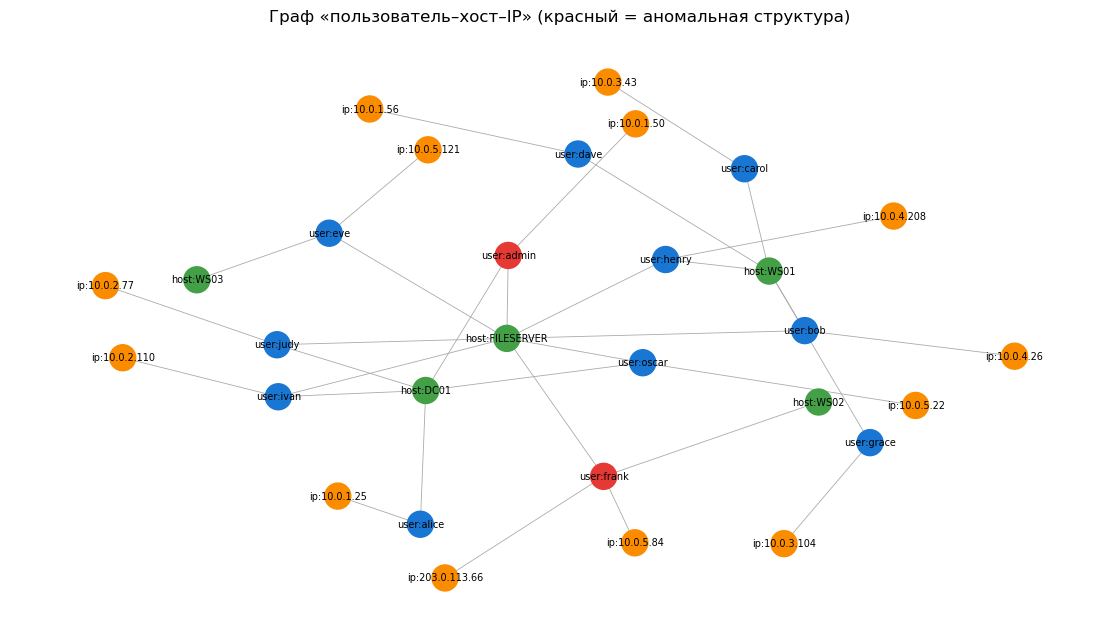

In [194]:
plt.figure(figsize=(11, 6))
sub_nodes = [n for n in G_simple if G_simple.nodes[n].get("kind") in {"user","host","ip"}]
H = G_simple.subgraph(sub_nodes).copy()
pos = nx.spring_layout(H, seed=2, k=0.7)
score_dict = dict(zip(node_scores["node"], node_scores["score"]))
threshold = np.percentile(scores,95)
node_colors = []
for n in H.nodes():
    if score_dict.get(n, 0) > threshold:
        node_colors.append("#e53935")
    elif H.nodes[n].get("kind") == "user":
        node_colors.append("#1976d2")
    elif H.nodes[n].get("kind") == "host":
        node_colors.append("#43a047")
    else:
        node_colors.append("#fb8c00")
nx.draw(H, pos, node_color=node_colors, with_labels=True, font_size=7,
        node_size=350, edge_color="#aaaaaa", width=0.6)
plt.title("Граф «пользователь–хост–IP» (красный = аномальная структура)")
plt.tight_layout(); plt.show()

## 6. Знакомство с датасетом OTRF Security Datasets (Mordor)

Датасет Mordor и набор интсрументов MSTICPy - это один из наиболее продвинутых инструментариев для анализа событий в среде Python. 
Для начала необходимо установить модуль MSTICPy. Этот модуль не входит в репозиторий conda, поэтому установка производится командой pip



In [195]:
from msticpy.data import QueryProvider

In [196]:
mdr_data = QueryProvider("Mordor")
mdr_data.connect()

Retrieving Mitre data...


C:\Users\ndomukhovsky\AppData\Local\anaconda3\envs\DA\Lib\site-packages\msticpy\data\drivers\mordor_driver.py:912: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mitre["x_mitre_deprecated"].fillna(False, inplace=True)
C:\Users\ndomukhovsky\AppData\Local\anaconda3\envs\DA\Lib\site-packages\msticpy\data\drivers\mordor_driver.py:912: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future beha

Retrieving Mordor data...


In [199]:
mdr_data.list_queries()

['atomic.aws.collection.ec2_proxy_s3_exfiltration',
 'atomic.aws.discovery.aws_s3_honeybucketlogs',
 'atomic.linux.defense_evasion.host.sh_binary_padding_dd',
 'atomic.linux.discovery.host.sh_arp_cache',
 'atomic.windows.collection.host.msf_record_mic',
 'atomic.windows.credential_access.host.cmd_copy_ntds_from_volume_shadow_copy',
 'atomic.windows.credential_access.host.cmd_dumping_ntds_dit_file_ntdsutil',
 'atomic.windows.credential_access.host.cmd_lsass_memory_dumpert_syscalls',
 'atomic.windows.credential_access.host.cmd_psexec_lsa_secrets_dump',
 'atomic.windows.credential_access.host.cmd_sam_copy_esentutl',
 'atomic.windows.credential_access.host.covenant_dcsync_dcerpc_drsuapi_DsGetNCChanges',
 'atomic.windows.credential_access.host.empire_dcsync_dcerpc_drsuapi_DsGetNCChanges',
 'atomic.windows.credential_access.host.empire_mimikatz_backupkeys_dcerpc_smb_lsarpc',
 'atomic.windows.credential_access.host.empire_mimikatz_extract_keys',
 'atomic.windows.credential_access.host.empire_

In [201]:
mdr_data.atomic.windows.collection.host.msf_record_mic()

https://raw.githubusercontent.com/OTRF/Security-Datasets/master/datasets/atomic/windows/collection/host/msf_record_mic.zip
Extracting msf_record_mic_2020-06-09225055.json


,ProcessId,ProcessGuid,@timestamp,RuleName,Task,Version,Domain,EventTypeOrignal,Keywords,AccountName,TargetObject,SourceName,port,UserID,Hostname,tags,EventTime,ExecutionProcessID,Image,Details,SeverityValue,Severity,EventID,@version,EventReceivedTime,RecordNumber,SourceModuleType,ThreadID,host,Message,...,QueryResults,QueryStatus,RuleAttr,RuleId,CalloutName,FilterId,Action,LayerKey,CalloutKey,UserSid,Weight,ProviderName,ChangeType,LayerId,FilterName,ProviderKey,FilterType,Conditions,UserName,FilterKey,TaskName,TaskContentNew,OperationType,NewValue,ObjectValueName,NewValueType,OldValue,OldValueType,param4,param3
0,6196,{6a910b9d-498a-5ee0-c903-000000000400},2020-06-10T02:50:56.537Z,-,13,2,NT AUTHORITY,INFO,-9223372036854775808,SYSTEM,\REGISTRY\A\{361c92d4-b0d9-fc34-0cf8-30ca2aeb8...,Microsoft-Windows-Sysmon,62387,S-1-5-18,WORKSTATION6.mordor.local,[mordorDataset],2020-06-09 22:50:54,3500,C:\Windows\SystemApps\Microsoft.Windows.Cortan...,Binary Data,2,INFO,13,1,2020-06-09 22:50:56,713650,im_msvistalog,4168,wec.internal.cloudapp.net,Registry value set:\r\nRuleName: -\r\nEventTyp...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6196,{6a910b9d-498a-5ee0-c903-000000000400},2020-06-10T02:50:56.537Z,-,12,2,NT AUTHORITY,INFO,-9223372036854775808,SYSTEM,HKU\S-1-5-21-526538150-889687948-186688817-110...,Microsoft-Windows-Sysmon,62387,S-1-5-18,WORKSTATION6.mordor.local,[mordorDataset],2020-06-09 22:50:54,3500,C:\Windows\SystemApps\Microsoft.Windows.Cortan...,NaN,2,INFO,12,1,2020-06-09 22:50:56,713651,im_msvistalog,4168,wec.internal.cloudapp.net,Registry object added or deleted:\r\nRuleName:...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6196,{6a910b9d-498a-5ee0-c903-000000000400},2020-06-10T02:50:56.537Z,-,13,2,NT AUTHORITY,INFO,-9223372036854775808,SYSTEM,HKU\S-1-5-21-526538150-889687948-186688817-110...,Microsoft-Windows-Sysmon,62387,S-1-5-18,WORKSTATION6.mordor.local,[mordorDataset],2020-06-09 22:50:54,3500,C:\Windows\SystemApps\Microsoft.Windows.Cortan...,C:\Users\sbeavers\AppData\Local\Packages\Micro...,2,INFO,13,1,2020-06-09 22:50:56,713652,im_msvistalog,4168,wec.internal.cloudapp.net,Registry value set:\r\nRuleName: -\r\nEventTyp...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6196,{6a910b9d-498a-5ee0-c903-000000000400},2020-06-10T02:50:56.537Z,-,13,2,NT AUTHORITY,INFO,-9223372036854775808,SYSTEM,HKU\S-1-5-21-526538150-889687948-186688817-110...,Microsoft-Windows-Sysmon,62387,S-1-5-18,WORKSTATION6.mordor.local,[mordorDataset],2020-06-09 22:50:54,3500,C:\Windows\SystemApps\Microsoft.Windows.Cortan...,C:\Users\sbeavers\AppData\Local\Packages\Micro...,2,INFO,13,1,2020-06-09 22:50:56,713653,im_msvistalog,4168,wec.internal.cloudapp.net,Registry value set:\r\nRuleName: -\r\nEventTyp...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6196,{6a910b9d-498a-5ee0-c903-000000000400},2020-06-10T02:50:56.538Z,-,13,2,NT AUTHORITY,INFO,-9223372036854775808,SYSTEM,HKU\S-1-5-21-526538150-889687948-186688817-110...,Microsoft-Windows-Sysmon,62387,S-1-5-18,WORKSTATION6.mordor.local,[mordorDataset],2020-06-09 22:50:54,3500,C:\Windows\SystemApps\Microsoft.Windows.Cortan...,en-US,2,INFO,13,1,2020-06-09 22:50:56,713654,im_msvistalog,4168,wec.internal.cloudapp.net,Registry value set:\r\nRuleName: -\r\nEventTyp...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6197,3364,NaN,2020-06-10T02:52:56.911Z,NaN,12810,0,NaN,NaN,-92143